In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
#load dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

#show first rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# shape of dataset
print(df.shape)

# column names
print(df.columns)

# information about data
df.info()

# statistical summary
df.describe()

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
# missing values
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [5]:
# duplicates
print(df.duplicated().sum())

# remove duplicates
df = df.drop_duplicates()

0


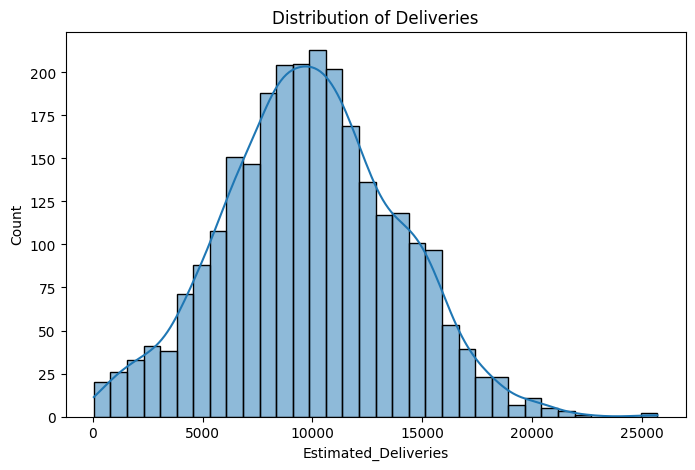

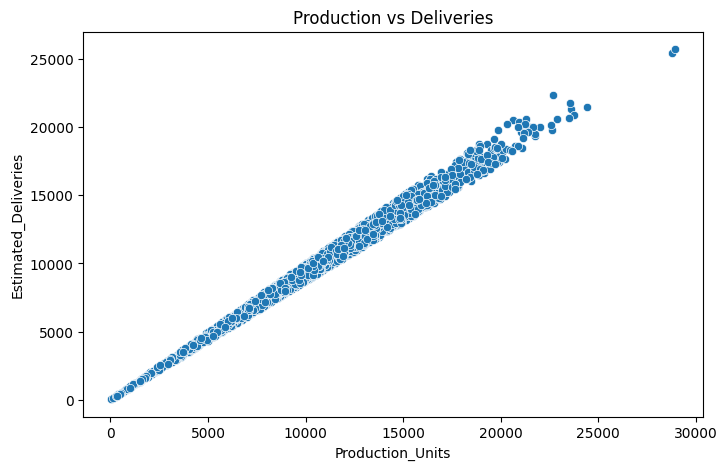

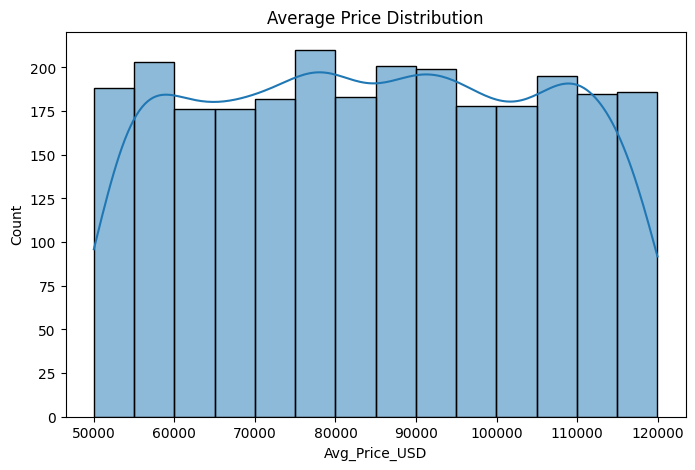

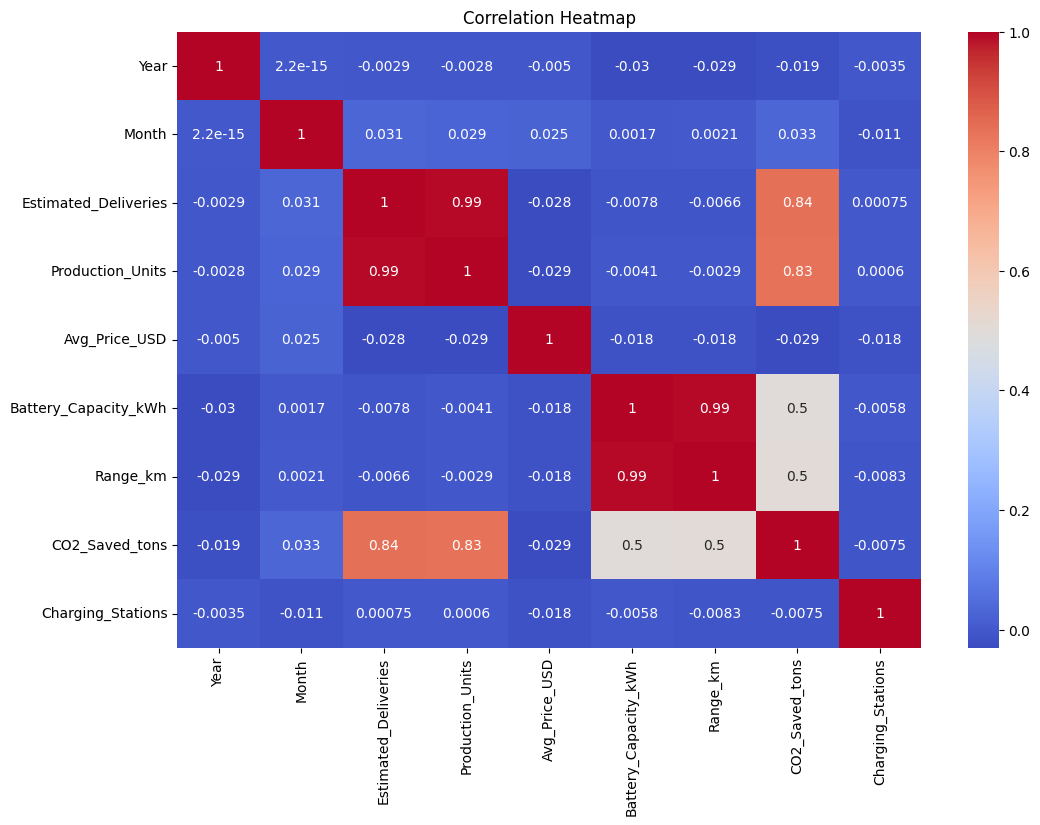

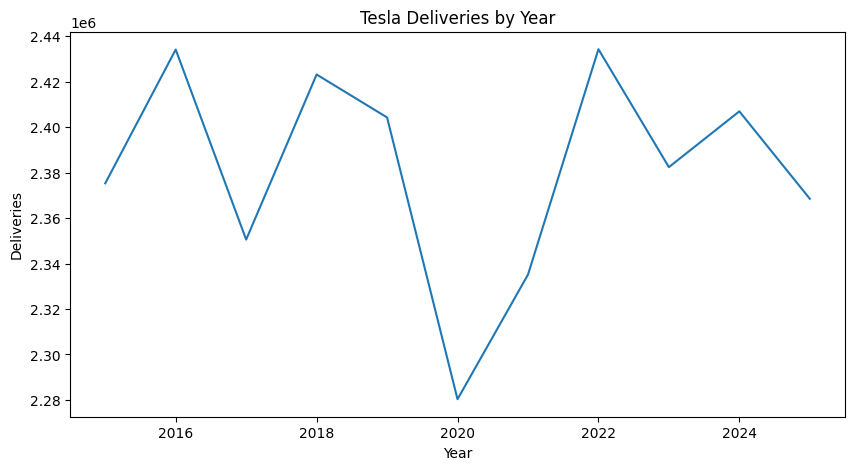

In [6]:
#EDA

#Delivery Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)

plt.title("Distribution of Deliveries")
plt.show()

#Production Vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Production_Units'],
    y=df['Estimated_Deliveries']
)

plt.title("Production vs Deliveries")
plt.show()

#Average Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'], kde=True)

plt.title("Average Price Distribution")
plt.show()

#Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#Deliveries by year
yearly_sales = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot()

plt.title("Tesla Deliveries by Year")
plt.ylabel("Deliveries")
plt.show()

In [7]:
#LabelEncoding
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region_Encoded'] = le_region.fit_transform(df['Region'])
df['Model_Encoded'] = le_model.fit_transform(df['Model'])
df['Source_Encoded'] = le_source.fit_transform(df['Source_Type'])

In [8]:
#FeatureEngineering

#lag_feature
df = df.sort_values(by=['Year', 'Month'])
df['Lag_Deliveries'] = df['Estimated_Deliveries'].shift(1)

#rolling_Mean
df['Rolling_Mean'] = df['Estimated_Deliveries'].rolling(window=3).mean()
#rolling Standard Deviation
df['Rolling_Std'] = df['Estimated_Deliveries'].rolling(window=3).std()

df = df.dropna()

In [9]:
#selecting features 
X = df[[
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Year',
    'Month',
    'Region_Encoded',
    'Model_Encoded',
    'Source_Encoded',
    'Lag_Deliveries',
    'Rolling_Mean',
    'Rolling_Std'
]]

y = df['Estimated_Deliveries']

In [10]:
#split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [11]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Linear_regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

#evaluation
print("LINEAR REGRESSION")
mae = mean_absolute_error(y_test, linear_pred)
rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
r2 = r2_score(y_test, linear_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

LINEAR REGRESSION
MAE: 318.0303187794102
RMSE: 386.7285616022668
R2 Score: 0.988883947569006


In [13]:
#Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

#evaluation
print("RIDGE REGRESSION")
mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
r2 = r2_score(y_test, ridge_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

RIDGE REGRESSION
MAE: 317.25915107569944
RMSE: 386.1593607206064
R2 Score: 0.988916645492685


In [14]:
#LassoRegression 
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)

#evaluation
print("LASSO REGRESSION")
mae = mean_absolute_error(y_test, lasso_pred)
rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
r2 = r2_score(y_test, lasso_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

LASSO REGRESSION
MAE: 317.8980696262974
RMSE: 386.6744703979724
R2 Score: 0.9888870569261755


In [15]:
#CrossValidation
cv_scores = cross_val_score(
    linear_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores")
print(cv_scores)
print("Average Score")
print(cv_scores.mean())

Cross Validation Scores
[0.98945353 0.99110631 0.99032913 0.99153657 0.99078543]
Average Score
0.9906421942735462


In [16]:
#Tuning
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test_scaled)

Best Parameters
{'alpha': 0.1}


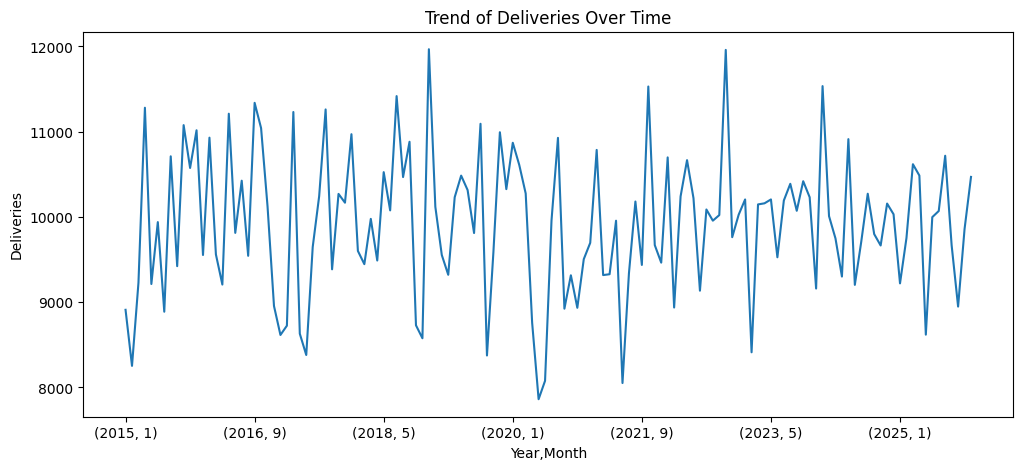

In [17]:
#timeSeriesAnalysis
monthly_trend = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].mean()

plt.figure(figsize=(12,5))
monthly_trend.plot()

plt.title("Trend of Deliveries Over Time")
plt.ylabel("Deliveries")
plt.show()

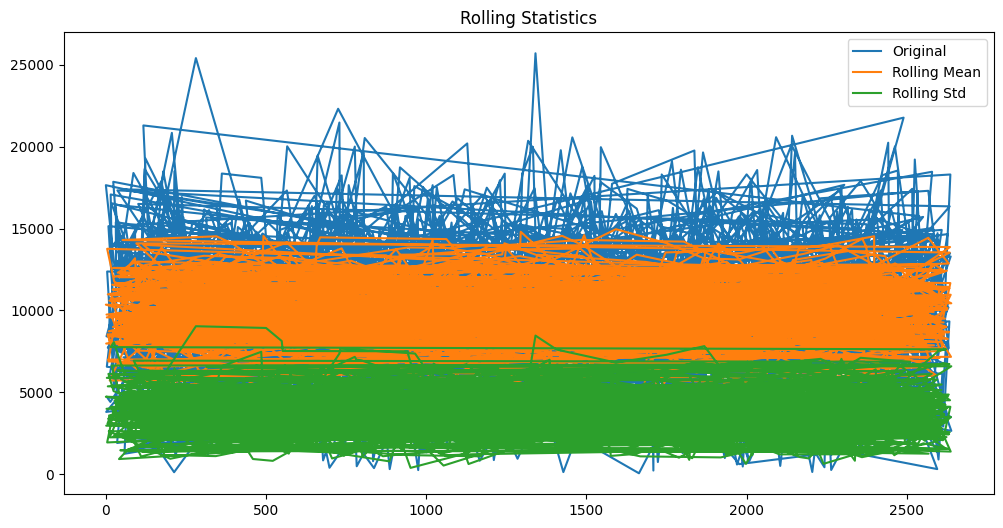

In [18]:
rolling_mean = df['Estimated_Deliveries'].rolling(window=5).mean()
rolling_std = df['Estimated_Deliveries'].rolling(window=5).std()

plt.figure(figsize=(12,6))
plt.plot(df['Estimated_Deliveries'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.title("Rolling Statistics")
plt.show()

In [19]:
#predicting

forecast_df = pd.DataFrame()

forecast_df['Actual'] = y_test.values
forecast_df['Predicted'] = best_pred
forecast_df.head()

,Actual,Predicted
0,9476,9068.822595
1,8179,8454.746832
2,14430,15095.904809
3,15912,16209.115596
4,15077,14606.349084


In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)
pipeline_pred = pipeline.predict(X_test)

print("PIPELINE MODEL")
print("R2 Score:")
print(r2_score(y_test, pipeline_pred))

PIPELINE MODEL
R2 Score:
0.988916645492685
